In [1]:
import json
from pathlib import Path
from datetime import datetime
from typing import Optional, Tuple, Dict

#from data.minbpe import BasicTokenizer as Tokenizer
from src.minbpe import RegexTokenizer as Tokenizer
from src.gpt import GPTLanguageModel

import matplotlib.pyplot as plt
import torch
torch.manual_seed(3647)
torch.set_float32_matmul_precision('high')
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
def now():
    return datetime.now().astimezone().strftime('%FT%T%:z')

def print_model_structure(model: nn.Module, indent: str = '') -> None:
    """
    Custom function to print model structure in a hierarchical format
    """
    for name, child in model.named_children():
        params = sum(p.numel() for p in child.parameters())
        print(f"{indent}├─ {name}: {child.__class__.__name__} ({params:,} parameters)")
        print_model_structure(child, indent + '│  ')

class TextDataset(Dataset):
    def __init__(self, data: torch.Tensor, block_size: int) -> None:
        self.data = data
        self.block_size = block_size

    def __len__(self) -> int:
        return len(self.data) - self.block_size

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        x = self.data[index:index + self.block_size]
        y = self.data[index + 1:index + self.block_size + 1]
        return x, y

def get_dataloaders(
        train_data: torch.Tensor,
        val_data: torch.Tensor,
        block_size: int,
        batch_size: int,
        device: torch.device,
) -> Tuple[DataLoader, DataLoader]:
    train_dataset = TextDataset(train_data.to(device), block_size)
    val_dataset = TextDataset(val_data.to(device), block_size)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

tokenizer_dir = Path("data") / "tokenizer"

checkpoint_dir = Path("data") / "ch03_checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

In [4]:
tokenizer = Tokenizer()
tokenizer.load(model_file=str(tokenizer_dir / "tokenizer.model"))

train_data = torch.load(tokenizer_dir / 'train.tokens.pt')
val_data = torch.load(tokenizer_dir / 'validation.tokens.pt')

print(f"--> train_data: {train_data.size()[0]:_}, val_data: {val_data.size()[0]:_}")

--> train_data: 12_092_088, val_data: 616_680


In [5]:
#### model parameters
parameters = {
  'vocab_size': len(tokenizer.vocab),
  'n_embd': 128,
  'block_size': 512,
  'n_head': 8,
  'n_layer': 2,
  'dropout': 0.2,
}

#### training parameters
iter_start, max_iters = 1, 100_000
learning_rate = 5e-5
batch_size = 128
eval_interval = 1_000
eval_iters = 500
save_interval = 1_000

model = GPTLanguageModel(
    vocab_size=parameters['vocab_size'],
    block_size=parameters['block_size'],
    n_embd=parameters['n_embd'],
    n_head=parameters['n_head'],
    n_layer=parameters['n_layer'],
    dropout=parameters['dropout'],
    device=device,
).to(device)

model = torch.compile(model)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

num_parameters = sum(p.numel() for p in model.parameters()) / 1e6
print(f'--> {num_parameters:_.3}M parameters')
# print_model_structure(model)

--> 0.726M parameters


In [6]:
checkpoints = sorted(
    checkpoint_dir.glob("checkpoint_*.pt"),
    key=lambda x: x.stat().st_ctime,
    #key=lambda x: int(x.name.split("-")[1]),
    reverse=True,
)

if len(checkpoints) > 0:
    last_ckpt = torch.load(checkpoints[0], map_location=device)
    iter_start = checkpoints[0].name.replace("checkpoint_", "").replace(".pt", "").split("-", 1)[0]
    iter_start = int(iter_start)
    meta = last_ckpt['meta']
    print(f"--> Resume from checkpoint: path={checkpoints[0]}, created_at={meta['created_at']}")
    print(f"    iter_start={iter_start}")

    model.load_state_dict(last_ckpt['model_state_dict'])
    optimizer.load_state_dict(last_ckpt['optimizer_state_dict'])
else:
    print("No last checkpoints found")

--> Resume from checkpoint: path=data/ch03_checkpoints/checkpoint_082000.pt, created_at=2025-09-03T14:26:11+08:00
    iter_start=82000


In [7]:
def get_batch(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    block_size = parameters['block_size']
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    index = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in index])
    y = torch.stack([data[i+1:i+block_size+1] for i in index])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss(eval_iters: int) -> Dict:
    output = {}
    model.eval()

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[k] = loss.item()

        output[split] = losses.mean()

    model.train()
    return output

In [8]:
train_loader, val_loader = get_dataloaders(
    train_data=train_data,
    val_data=val_data,
    block_size=parameters['block_size'],
    batch_size=batch_size,
    device=device,
)

train_losses, val_losses = [], []

In [9]:
print(f"--> Start training: iter_start={iter_start:07_}, max_iters={max_iters:07_}")

for iteration in range(iter_start, max_iters):
    step = iteration + 1

    if step % eval_interval == 0 or step == max_iters:
        losses = estimate_loss(eval_iters)

        print("{} step {:07_}/{:07_}: train_loss={:.3f}, validation_loss={:.3f}".format(
            now(), step, max_iters, losses['train'], losses['val'],
        ))

        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

    x_batch, y_batch = get_batch('train')
    logits, loss = model(x_batch, y_batch)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    # batch_loss = loss.item()

    if step % save_interval != 0:
        continue

    losses = estimate_loss(eval_iters)
    checkpoint_prefix = str(checkpoint_dir / f"checkpoint_{step:06}")

    meta = {
        'created_at': now(),
        'parameters': parameters,
        'train_loss': float(losses['train']),
        'validation_loss': float(losses['val']),
    }

    checkpoint = {
        'meta': meta,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }

    with open(checkpoint_prefix + ".json", 'w', encoding='utf-8') as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    torch.save(checkpoint, checkpoint_prefix+".pt")
    print(f"{now()} saved checkpoint: {checkpoint_prefix}.pt")

--> Start training: iter_start=082_000, max_iters=100_000
2025-09-03T14:33:36+08:00 step 083_000/100_000: train_loss=2.606, validation_loss=2.768
2025-09-03T14:34:16+08:00 saved checkpoint: data/ch03_checkpoints/checkpoint_083000.pt
2025-09-03T14:36:57+08:00 step 084_000/100_000: train_loss=2.607, validation_loss=2.766
2025-09-03T14:37:38+08:00 saved checkpoint: data/ch03_checkpoints/checkpoint_084000.pt
2025-09-03T14:40:19+08:00 step 085_000/100_000: train_loss=2.605, validation_loss=2.765
2025-09-03T14:40:59+08:00 saved checkpoint: data/ch03_checkpoints/checkpoint_085000.pt
2025-09-03T14:43:40+08:00 step 086_000/100_000: train_loss=2.602, validation_loss=2.760
2025-09-03T14:44:20+08:00 saved checkpoint: data/ch03_checkpoints/checkpoint_086000.pt
2025-09-03T14:47:01+08:00 step 087_000/100_000: train_loss=2.601, validation_loss=2.763
2025-09-03T14:47:42+08:00 saved checkpoint: data/ch03_checkpoints/checkpoint_087000.pt
2025-09-03T14:50:23+08:00 step 088_000/100_000: train_loss=2.599, v

In [22]:
input_tokens = tokenizer.encode("Hello ")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

Hello x, where it is known as the name. Software is really important kind of colorer here to swhile bound throughout truth, something can be done on letters such as waking, waking up swhere, spottal pot with prompt on What is suited to be healthy, can I tell further I should


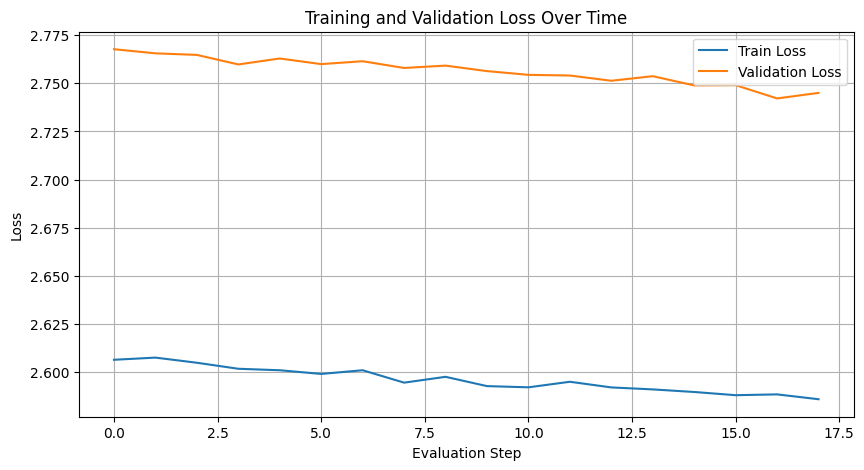

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss") # marker='o'
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

# 001_000: train_loss=4.38, validation_loss=4.41
# 003_000: train_loss=3.75, validation_loss=3.82
# 005_000: train_loss=3.37, validation_loss=3.47
# 010_000: train_loss=3.08, validation_loss=3.21
# 050_000: train_loss=2.67, validation_loss=2.84
# 100_000: train_loss=2.58, validation_loss=2.74